In [2]:
import numpy as np
import matplotlib.pyplot as plt
import fastf1
import pandas as pd

In [3]:
# get drs data from fastf1 api, visualise it for exploration purposes.
# set the position for the cache
fastf1.Cache.enable_cache('../fastf1_cache')

In [4]:
# example in a qualifying session 


In [15]:
# example using the same data used by Abhay in discreteLapbyLapResetTyre.py
YEAR = 2023
GP = "Spain"
SESSION = "R"
DRIVER = "VER"

def build_driver_car_data(year, gp, session_name, driver):
    session = fastf1.get_session(year, gp, session_name)
    session.load()

    laps = session.laps.pick_drivers(driver)
    lap_car_data = []

    for _, lap in laps.iterlaps():
        car_data = lap.get_car_data()
        car_data['Driver'] = lap['Driver']
        car_data['LapNumber'] = lap['LapNumber']
        lap_car_data.append(car_data)

    car_data_df = pd.concat(lap_car_data, ignore_index=True)
    return session, laps, lap_car_data, car_data_df


def visualise_drs_data(
    car_data_df,
    driver,
    gp,
    year,
    session_name,
    lap_numbers=None,
    drop_first_n_laps=2,
    fig_size=(10, 6),
):
    """Visualise DRS usage by lap average and per-lap traces."""
    print(car_data_df.head())

    drs_activation_by_lap = car_data_df.groupby('LapNumber')['DRS'].mean()
    if drop_first_n_laps > 0:
        drs_activation_by_lap = drs_activation_by_lap[drop_first_n_laps:]

    plt.figure(figsize=fig_size)
    plt.plot(drs_activation_by_lap.index, drs_activation_by_lap.values, marker='o')
    plt.xlabel('Lap Number')
    plt.ylabel('Mean DRS Activation')
    plt.title(f'DRS Activation for {driver} in {gp} {year} {session_name}')
    plt.grid()
    plt.show()

    if lap_numbers is None:
        lap_numbers = sorted(car_data_df['LapNumber'].dropna().unique())

    plt.figure(figsize=fig_size)
    for lap_number in lap_numbers:
        lap_data = car_data_df[car_data_df['LapNumber'] == lap_number].reset_index(drop=True)
        if lap_data.empty:
            continue
        plt.plot(lap_data.index, lap_data['DRS'], label=f'Lap {int(lap_number)}')

    plt.legend()
    plt.xlabel('Index of the data point in the lap')
    plt.ylabel('DRS Activation level')
    plt.title(f'DRS Activation for {driver} in {gp} {year} {session_name}')
    plt.grid()
    plt.show()

    return drs_activation_by_lap


session, laps, lap_car_data, car_data_df = build_driver_car_data(YEAR, GP, SESSION, DRIVER)

core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 00:00.037000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '44', '63', '11', '55', '18', '14', '31', '24', '10', '16', '2

/var/folders/63/__1p4tt55zq_byscd0qttqcc0000gn/T/ipykernel_91385/1645666005.py:38: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  drs_activation_by_lap = drs_activation_by_lap[drop_first_n_laps:]


                     Date      RPM  Speed  nGear  Throttle  Brake  DRS Source  \
0 2023-06-04 13:03:16.150  10072.0    0.0      1      16.0   True    1    car   
1 2023-06-04 13:03:16.550   8862.0    5.0      1      17.0  False    1    car   
2 2023-06-04 13:03:16.990   5782.0   17.0      1      18.0  False    1    car   
3 2023-06-04 13:03:17.230   4600.0   26.0      1      21.0  False    1    car   
4 2023-06-04 13:03:17.510   4266.0   37.0      1      30.0  False    1    car   

                    Time            SessionTime  LapNumber  
0 0 days 00:00:00.180000 0 days 01:02:16.143000        1.0  
1 0 days 00:00:00.580000 0 days 01:02:16.543000        1.0  
2 0 days 00:00:01.020000 0 days 01:02:16.983000        1.0  
3 0 days 00:00:01.260000 0 days 01:02:17.223000        1.0  
4 0 days 00:00:01.540000 0 days 01:02:17.503000        1.0  


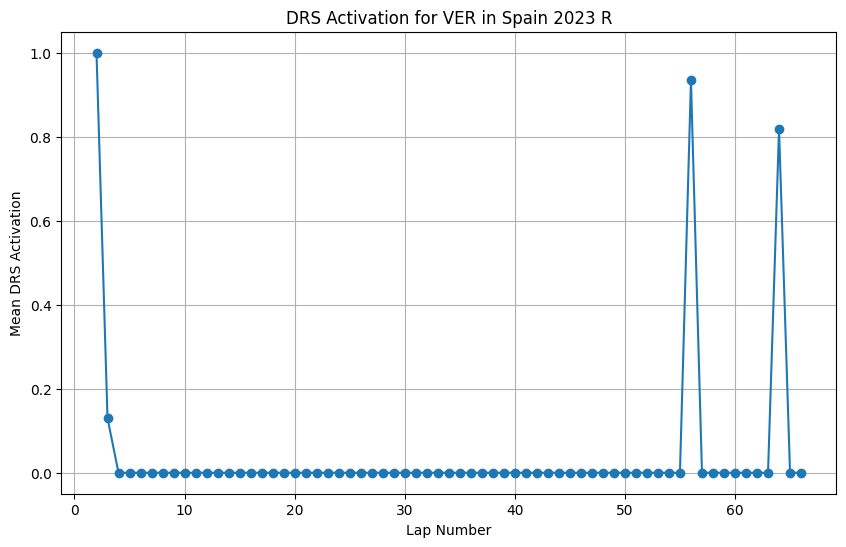

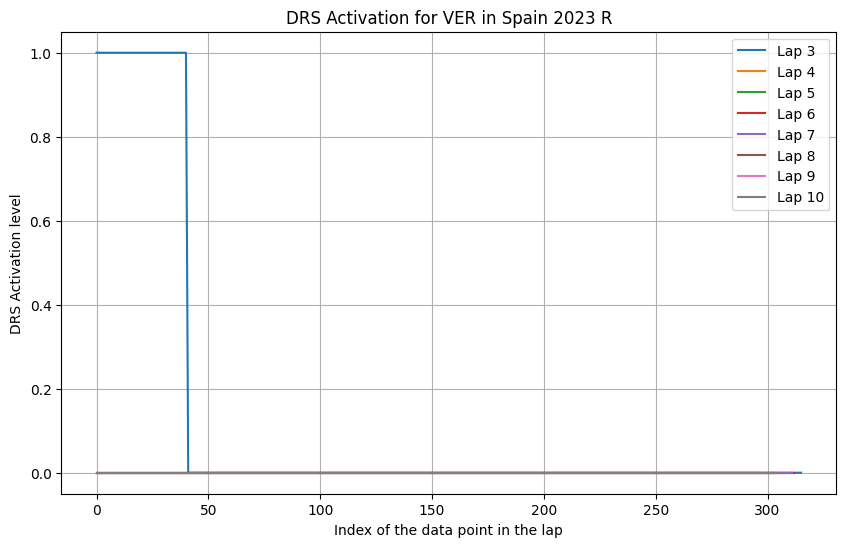

In [6]:
# call the reusable DRS visualisation function
drs_activation_by_lap = visualise_drs_data(
    car_data_df=car_data_df,
    driver=DRIVER,
    gp=GP,
    year=YEAR,
    session_name=SESSION,
    lap_numbers=[3, 4, 5, 6, 7, 8, 9, 10],
    drop_first_n_laps=2,
)

core           INFO 	Loading data for Spanish Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '55', '4', '10', '44', '18', '31', '27', '14', '81', '11', '63', '24', '21', '22', '77', '20', '23', '16', '2']


                     Date     RPM  Speed  nGear  Throttle  Brake  DRS Source  \
0 2023-06-03 14:01:05.426  3460.0    9.0      1       0.0  False    8    car   
1 2023-06-03 14:01:05.746  3529.0    9.0      1       0.0  False    8    car   
2 2023-06-03 14:01:05.946  3482.0    9.0      1       0.0  False    8    car   
3 2023-06-03 14:01:06.185  3474.0    9.0      1       0.0  False    8    car   
4 2023-06-03 14:01:06.345  3450.0    9.0      1       0.0  False    8    car   

                    Time            SessionTime  LapNumber  
0 0 days 00:00:00.279000 0 days 00:16:05.417000        1.0  
1 0 days 00:00:00.599000 0 days 00:16:05.737000        1.0  
2 0 days 00:00:00.799000 0 days 00:16:05.937000        1.0  
3 0 days 00:00:01.038000 0 days 00:16:06.176000        1.0  
4 0 days 00:00:01.198000 0 days 00:16:06.336000        1.0  


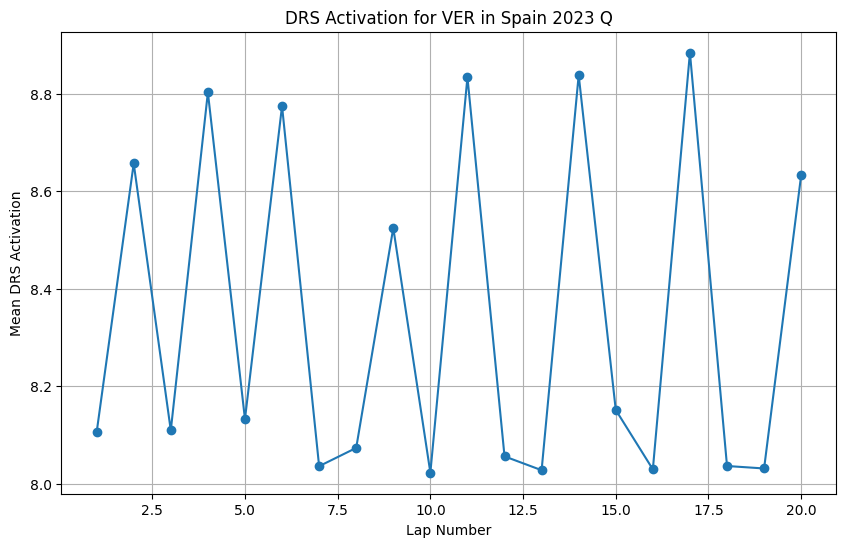

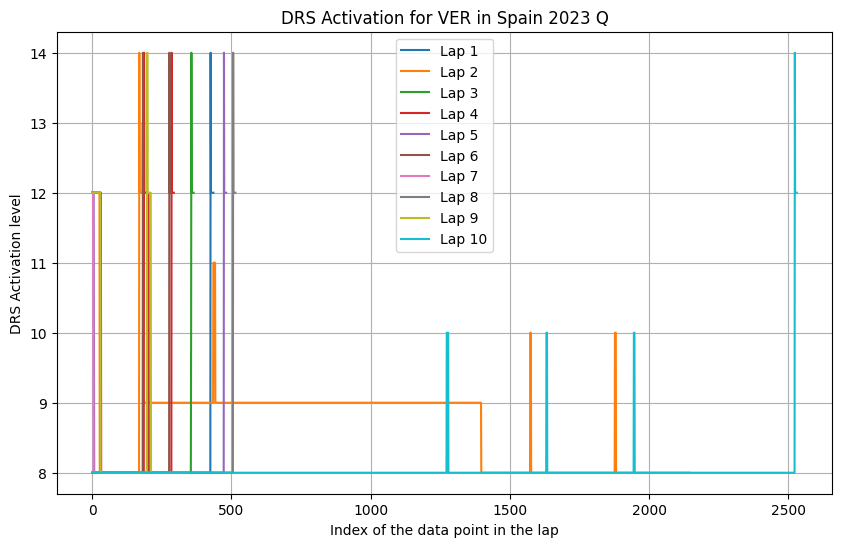

LapNumber
1.0     8.105505
2.0     8.657036
3.0     8.109589
4.0     8.802721
5.0     8.132780
6.0     8.774648
7.0     8.036290
8.0     8.073786
9.0     8.524781
10.0    8.022916
11.0    8.833948
12.0    8.056452
13.0    8.028074
14.0    8.838235
15.0    8.151603
16.0    8.029798
17.0    8.884058
18.0    8.036697
19.0    8.031632
20.0    8.633229
Name: DRS, dtype: float64

In [7]:
# get car data and visualise DRS for a qualification session

session_type = "Q"

session, laps, lap_car_data, car_data_df = build_driver_car_data(YEAR, GP, session_type, DRIVER)
visualise_drs_data(
    car_data_df=car_data_df,
    driver=DRIVER,
    gp=GP,
    year=YEAR,
    session_name=session_type,
    lap_numbers=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    drop_first_n_laps=0,
)

In [11]:
print(car_data_df.head())

                     Date      RPM  Speed  nGear  Throttle  Brake  DRS Source  \
0 2023-06-04 13:03:16.150  10072.0    0.0      1      16.0   True    1    car   
1 2023-06-04 13:03:16.550   8862.0    5.0      1      17.0  False    1    car   
2 2023-06-04 13:03:16.990   5782.0   17.0      1      18.0  False    1    car   
3 2023-06-04 13:03:17.230   4600.0   26.0      1      21.0  False    1    car   
4 2023-06-04 13:03:17.510   4266.0   37.0      1      30.0  False    1    car   

                    Time            SessionTime  LapNumber  
0 0 days 00:00:00.180000 0 days 01:02:16.143000        1.0  
1 0 days 00:00:00.580000 0 days 01:02:16.543000        1.0  
2 0 days 00:00:01.020000 0 days 01:02:16.983000        1.0  
3 0 days 00:00:01.260000 0 days 01:02:17.223000        1.0  
4 0 days 00:00:01.540000 0 days 01:02:17.503000        1.0  


In [19]:
# plot for all drivers in the race, on one lap
# get all drivers in the 2023 Spanish gp
session = fastf1.get_session(YEAR, GP, SESSION)
session.load()
driver_list = session.laps['Driver'].unique()

session, laps, lap_car_data, car_data_df = build_driver_car_data(YEAR, GP, SESSION, driver=driver_list)

core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 00:00.037000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '44', '63', '11', '55', '18', '14', '31', '24', '10', '16', '2

Index(['Date', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source',
       'Time', 'SessionTime', 'Driver', 'LapNumber'],
      dtype='object')


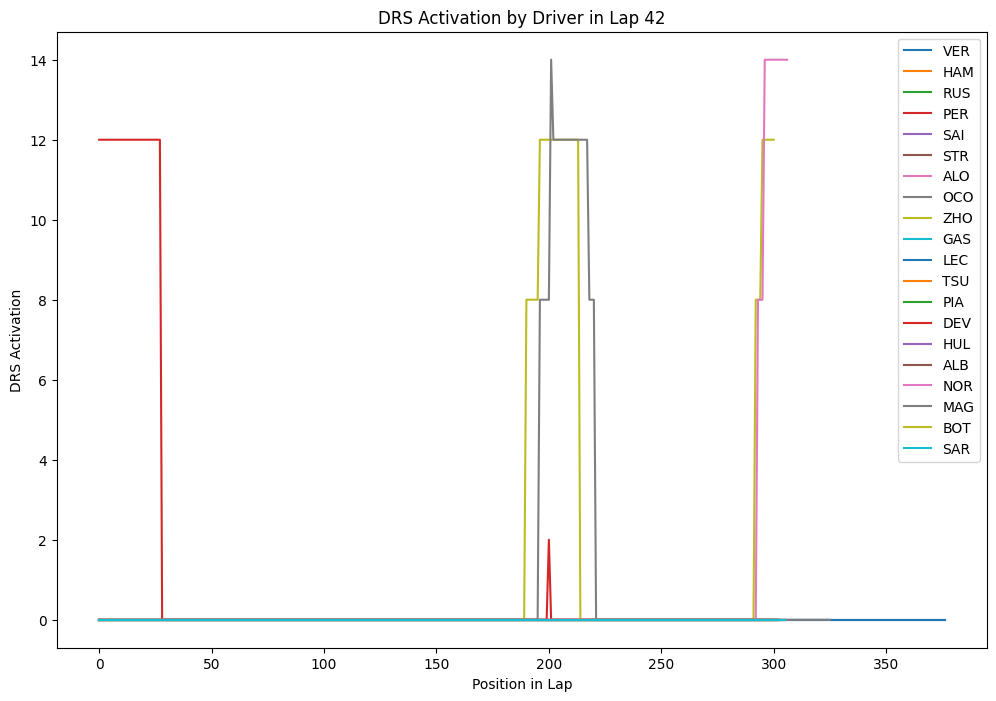

In [26]:
# plot for all drivers in the race, on one lap
lap_number = 42  # Example lap number to plot
print(car_data_df.columns)
fig, ax = plt.subplots(figsize=(12, 8))
for driver in driver_list:
    driver_data = car_data_df[car_data_df['Driver'] == driver]
    lap_data = driver_data[driver_data['LapNumber'] == lap_number].reset_index(drop=True)
    if lap_data.empty:
        continue
    ax.plot(lap_data.index, lap_data['DRS'], label=driver)
ax.set_xlabel('Position in Lap')
ax.set_ylabel('DRS Activation')
ax.set_title('DRS Activation by Driver in Lap {}'.format(lap_number))
ax.legend()
plt.show()

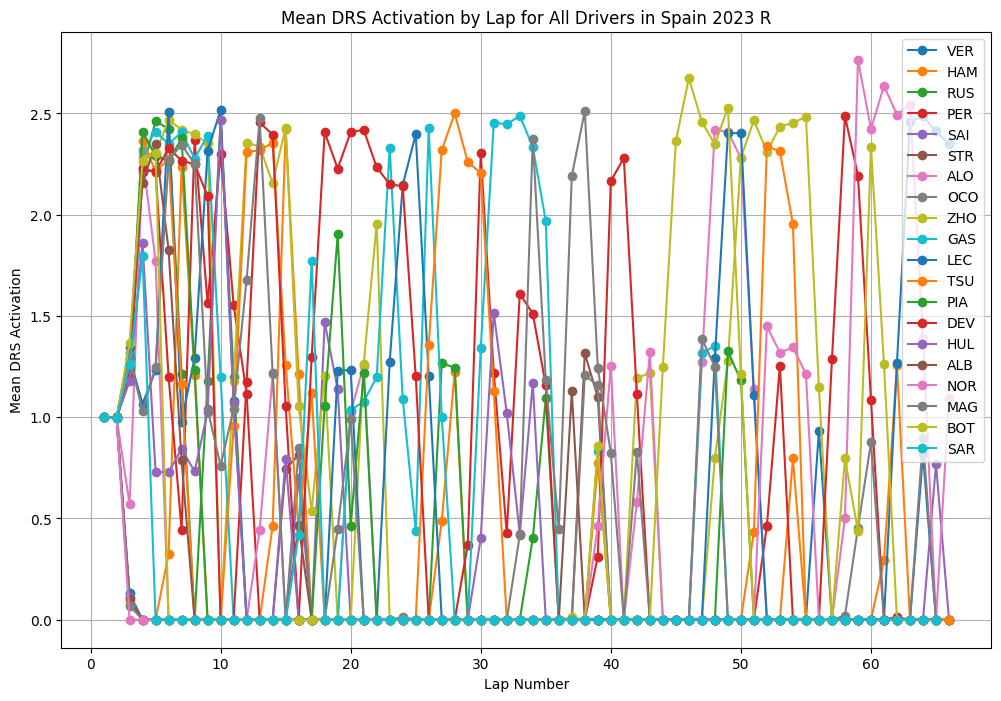

In [27]:
# plot the mean DRS activation by lap for all drivers
plt.figure(figsize=(12, 8))
for driver in driver_list:
    driver_data = car_data_df[car_data_df['Driver'] == driver]
    drs_activation_by_lap = driver_data.groupby('LapNumber')['DRS'].mean()
    plt.plot(drs_activation_by_lap.index, drs_activation_by_lap.values, marker='o', label=driver)
plt.xlabel('Lap Number')
plt.ylabel('Mean DRS Activation')
plt.title(f'Mean DRS Activation by Lap for All Drivers in {GP} {YEAR} {SESSION}')
plt.legend()
plt.grid()
plt.show()

Questions: what decides what level to set DRS at ? Can we assume that it is always either at max or not?